In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [5]:
import os
os.getcwd()

'c:\\Users\\Dell\\Desktop\\Mutual Fund Analytics\\Notebook'

In [6]:
import os

os.listdir("../Data")

['data_dictionary.md', 'Processed', 'Raw']

In [7]:
os.listdir("../Data/Processed")

['02_nav_history_clean.csv',
 '07_scheme_performance_clean.csv',
 '08_investor_transactions_clean.csv']

In [8]:
nav = pd.read_csv("../Data/Processed/02_nav_history_clean.csv")
performance = pd.read_csv("../Data/Processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../Data/Processed/08_investor_transactions_clean.csv")

In [9]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [10]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [11]:
nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [12]:
# Date format
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Daily Returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# VaR & CVaR Function
def calculate_var_cvar(group):
    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_report = nav.groupby("amfi_code").apply(calculate_var_cvar).reset_index()

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
var_cvar_report.to_csv("../Output/var_cvar_report.csv", index=False)

In [14]:
var_cvar_report.shape

(40, 3)

In [15]:
# Daily risk-free rate (6.5% annual)
rf_daily = 0.065 / 252

rolling_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .apply(lambda x: ((x.mean() - rf_daily) / x.std()) * np.sqrt(252), raw=False)
    .reset_index()
)

rolling_sharpe.rename(columns={"daily_return": "rolling_sharpe"}, inplace=True)

rolling_sharpe.head()

,amfi_code,level_1,rolling_sharpe
0,100016,0,NaN
1,100016,1,NaN
2,100016,2,NaN
3,100016,3,NaN
4,100016,4,NaN


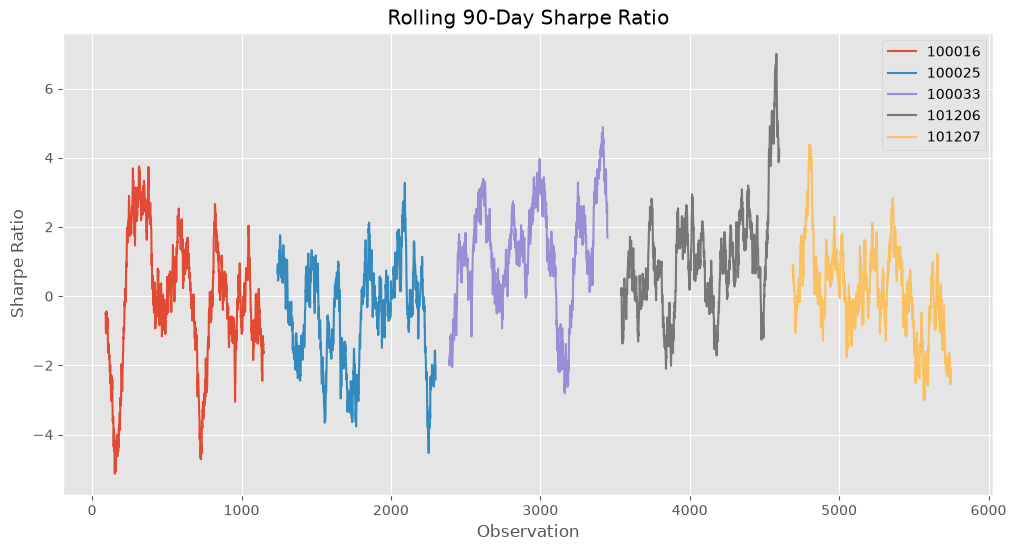

In [16]:
top5 = nav["amfi_code"].drop_duplicates().head(5)

plt.figure(figsize=(12,6))

for code in top5:
    temp = rolling_sharpe[rolling_sharpe["amfi_code"] == code]
    plt.plot(temp["level_1"], temp["rolling_sharpe"], label=str(code))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Observation")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../Output/rolling_sharpe_chart.png")
plt.show()

In [18]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status',
 'cohort_year']

In [19]:
cohort = transactions.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    top_fund=("amfi_code", lambda x: x.mode().iloc[0])
)

cohort

,avg_sip_amount,total_invested,top_fund
cohort_year,,,
2024,107422.541832,3491125187,148568
2025,109158.577061,30455243,119599


In [20]:
cohort.head()

,avg_sip_amount,total_invested,top_fund
cohort_year,,,
2024,107422.541832,3491125187,148568
2025,109158.577061,30455243,119599


In [21]:
sip = transactions[transactions["transaction_type"]=="SIP"].copy()

sip = sip.sort_values(["investor_id","transaction_date"])

sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

sip_summary = sip.groupby("investor_id").agg(
    sip_count=("transaction_date","count"),
    avg_gap=("gap_days","mean")
)

sip_summary["status"] = np.where(
    (sip_summary["sip_count"]>=6) &
    (sip_summary["avg_gap"]>35),
    "At Risk",
    "Healthy"
)

sip_summary.head()

,sip_count,avg_gap,status
investor_id,,,
INV000001,2,76.0,Healthy
INV000002,3,207.0,Healthy
INV000003,2,238.0,Healthy
INV000004,6,85.4,At Risk
INV000005,3,14.0,Healthy


In [22]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [23]:
def recommend_funds(risk):

    result = performance[
        performance["risk_grade"].str.lower() == risk.lower()
    ]

    result = result.sort_values(
        "sharpe_ratio",
        ascending=False
    )[["scheme_name","fund_house","risk_grade","sharpe_ratio"]]

    return result.head(3)

recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03
